# E-commerce Funnel & Marketing Performance Analysis

## Project Overview

This project explores a marketing funnel dataset from Olist sellers who requested contact to start selling their products on the Olist platform.

The dataset contains around 8,000 Marketing Qualified Leads (MQLs) collected between June 2017 and June 2018. Each record represents a potential seller that entered the company's sales funnel.

---

## Funnel Process

The seller journey follows several stages:

1. A seller signs up through a landing page.
2. A Sales Development Representative (SDR) contacts the lead.
3. The lead confirms information and schedules a consultation.
4. A Sales Representative (SR) conducts the consultation.
5. The deal is either won or lost.
6. Successful leads become sellers on Olist and start publishing products.

---

## Main Goals of the Analysis

The purpose of this project is to analyze the performance of the marketing and sales funnel and identify the factors that influence conversions and revenue.

Key business questions:

1. Which marketing channels are the most effective?
2. Which channels generate the highest revenue?
3. How does revenue change over time for different channels?
4. What are the monthly revenue trends?
5. How long does it take for a lead to become a customer?
6. How many sales are made each month?
7. How do business segments behave inside the funnel?
8. Which customer groups place more orders?
9. Which groups generate higher payments?
10. Which business types produce the most revenue?

### Data wrangling and cleaning

## Database Connection

A connection to the PostgreSQL database is created using SQLAlchemy. This allows running SQL queries directly from the notebook.

## Database

- PostgreSQL database: `analytics`

This connection will be used for all data extraction steps in the project.

In [344]:
from sqlalchemy import create_engine
from sqlalchemy import text
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style('darkgrid', {'grid.linestyle': '--'})

engine = create_engine("postgresql://invoke@localhost:5432/analytics")

## Loading the Data

The required tables are loaded from PostgreSQL into Pandas DataFrames.

- `mql_leads` contains information about marketing qualified leads.
- `mql_deals` contains information about closed deals and sales details.

These datasets will be used for further cleaning, exploration, and funnel analysis.

## Working  on "olist_closed_leads_dataset" cleaning 

In [180]:
# Check data quality: total rows and missing values in key columns
query = """
    SELECT
    COUNT(*) AS total,
    COUNT(mql_id) AS mql_id_not_null,
    COUNT(origin) AS origin_not_null,
    COUNT(landing_page_id) AS landing_not_null
FROM mql_leads; """
df = pd.read_sql(query , engine)
df

,total,mql_id_not_null,origin_not_null,landing_not_null
0,8000,8000,7940,8000


In [3]:
query = """
    SELECT
        *
    FROM mql_leads
    LIMIT 10; """
df = pd.read_sql(query , engine)
df

,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search
5,28bdfd5f057764b54c38770f95c69f2f,2018-01-14,22c29808c4f815213303f8933030604c,organic_search
6,126a0d10becbaafcb2e72ce6848cf32c,2018-05-15,6a110e795dd487f1cf8d7583671987af,email
7,f76136f54d14a3345951f25b7932366b,2018-05-24,d51b0d02f063ba1d053db6d97226eec3,email
8,2f838cade4a6012a6cb1016d1d8d95ed,2017-11-10,aeac92c0f5ae22a04ed3b746cce3a1b6,organic_search
9,7281942387a1a0c3f72a50a8b0bb0920,2017-12-25,88740e65d5d6b056e0cda098e1ea6313,social


In [4]:
# No dublicated rows

query = """
    SELECT
    COUNT(*)
FROM (SELECT
        DISTINCT *
      FROM mql_leads
     ) t ; """ 
df = pd.read_sql(query , engine)
df

,count
0,8000


In [23]:
# Check dublicated in each column


def check_unique(column_name, table_name):
    query = f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT({column_name}) AS non_null_values,
        COUNT(DISTINCT {column_name}) AS unique_values
    FROM {table_name}
    """
    return pd.read_sql(query, engine)

for col in leads.columns:
    df = check_unique(col, "mql_leads")
    print(f"\nColumn: {col}")
    print(df)


Column: mql_id
   total_rows  non_null_values  unique_values
0        8000             8000           8000

Column: first_contact_date
   total_rows  non_null_values  unique_values
0        8000             8000            336

Column: landing_page_id
   total_rows  non_null_values  unique_values
0        8000             8000            495

Column: origin
   total_rows  non_null_values  unique_values
0        8000             7940             10


In [267]:
# Check structure error

query = """
    SELECT
        DISTINCT(origin)
    FROM mql_leads
    """
df = pd.read_sql(query,engine)
df

,origin
0,None
1,direct_traffic
2,display
3,email
4,paid_search
5,other_publicities
6,referral
7,social
8,organic_search
9,other


No structre errors

In [268]:
#fill null values with unknown in origin and convert "first_contact_date" column to date_time column
#AND CREATE NEW TABLE

from sqlalchemy import text

query = """
DROP TABLE IF EXISTS clean_mql_leads;
CREATE TABLE clean_mql_leads AS
SELECT
    mql_id,
    first_contact_date::DATE AS first_contact_date,
    landing_page_id,
    COALESCE(origin, 'unknown') AS origin
FROM mql_leads;
"""

with engine.begin() as conn:
    conn.execute(text(query))

## "Marketing_qualified_leads" final look

In [269]:
query = """
    SELECT *
    FROM clean_mql_leads
    """
leads = pd.read_sql(query , engine)
leads.head()

,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search


In [63]:
leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   mql_id              8000 non-null   object
 1   first_contact_date  8000 non-null   object
 2   landing_page_id     8000 non-null   object
 3   origin              8000 non-null   object
dtypes: object(4)
memory usage: 250.1+ KB


### Working on "closed_deals" cleanig

In [270]:
query  = """
    SELECT *
    FROM mql_deals
"""
deals = pd.read_sql(query , engine)

deals.head()

,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26,pet,online_medium,cat,None,None,None,reseller,NaN,0.0
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08,car_accessories,industry,eagle,None,None,None,reseller,NaN,0.0
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05,home_appliances,online_big,cat,None,None,None,reseller,NaN,0.0
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17,food_drink,online_small,None,None,None,None,reseller,NaN,0.0
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03,home_appliances,industry,wolf,None,None,None,manufacturer,NaN,0.0


In [271]:
# Check dublicated in each column

for col in deals.columns:
    df = check_unique(col, "mql_deals")
    print(f"\nColumn: {col}")
    print(df)


Column: mql_id
   total_rows  non_null_values  unique_values
0         842              842            842

Column: seller_id
   total_rows  non_null_values  unique_values
0         842              842            842

Column: sdr_id
   total_rows  non_null_values  unique_values
0         842              842             32

Column: sr_id
   total_rows  non_null_values  unique_values
0         842              842             22

Column: won_date
   total_rows  non_null_values  unique_values
0         842              842            191

Column: business_segment
   total_rows  non_null_values  unique_values
0         842              841             33

Column: lead_type
   total_rows  non_null_values  unique_values
0         842              836              8

Column: lead_behaviour_profile
   total_rows  non_null_values  unique_values
0         842              665              9

Column: has_company
   total_rows  non_null_values  unique_values
0         842               63      

In [67]:
# Check structure error

def check_structure(column_name):
    query = f"""
    SELECT DISTINCT {column_name}
    FROM mql_deals
    """
    return pd.read_sql(query, engine)
    
for col in used_columns[3:]:
    print(f"\n{col}:")
    print(check_strct(col).squeeze().tolist())


business_segment:
['other', 'books', 'home_appliances', None, 'music_instruments', 'audio_video_electronics', 'watches', 'stationery', 'small_appliances', 'toys', 'health_beauty', 'bags_backpacks', 'car_accessories', 'party', 'gifts', 'home_office_furniture', 'games_consoles', 'food_supplement', 'religious', 'phone_mobile', 'computers', 'perfume', 'bed_bath_table', 'air_conditioning', 'fashion_accessories', 'food_drink', 'sports_leisure', 'home_decor', 'construction_tools_house_garden', 'pet', 'jewerly', 'household_utilities', 'baby', 'handcrafted']

lead_type:
[None, 'offline', 'online_small', 'online_big', 'online_top', 'online_beginner', 'industry', 'online_medium', 'other']

lead_behaviour_profile:
['shark', None, 'eagle, cat', 'shark, cat', 'shark, wolf', 'eagle, wolf', 'eagle', 'cat', 'wolf', 'cat, wolf']

business_type:
[None, 'reseller', 'other', 'manufacturer']


In [272]:
# No dublicated rows

query = """
    SELECT
    COUNT(*)
FROM (SELECT
        DISTINCT *
      FROM mql_deals
     ) t ; """ 
df = pd.read_sql(query , engine)
df

,count
0,842


In [273]:
query = """
DROP TABLE IF EXISTS clean_mql_deals;

CREATE TABLE clean_mql_deals AS
SELECT
    mql_id,
    won_date::DATE AS won_date,
    declared_monthly_revenue,
    COALESCE(business_segment, 'unknown') AS business_segment,
    COALESCE(lead_type, 'unknown') AS lead_type,
    COALESCE(lead_behaviour_profile, 'unknown') AS lead_behaviour_profile,
    COALESCE(business_type, 'unknown') AS business_type
FROM mql_deals;
"""

with engine.begin() as conn:
    conn.execute(text(query))

### Closed deals finel look 

In [274]:
query = """
    SELECT *
    FROM clean_mql_deals
    """
deals = pd.read_sql(query , engine)

deals.head()

,mql_id,won_date,declared_monthly_revenue,business_segment,lead_type,lead_behaviour_profile,business_type
0,5420aad7fec3549a85876ba1c529bd84,2018-02-26,0.0,pet,online_medium,cat,reseller
1,a555fb36b9368110ede0f043dfc3b9a0,2018-05-08,0.0,car_accessories,industry,eagle,reseller
2,327174d3648a2d047e8940d7d15204ca,2018-06-05,0.0,home_appliances,online_big,cat,reseller
3,f5fee8f7da74f4887f5bcae2bafb6dd6,2018-01-17,0.0,food_drink,online_small,unknown,reseller
4,ffe640179b554e295c167a2f6be528e0,2018-07-03,0.0,home_appliances,industry,wolf,manufacturer


In [75]:
deals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842 entries, 0 to 841
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   mql_id                    842 non-null    object 
 1   won_date                  842 non-null    object 
 2   declared_monthly_revenue  842 non-null    float64
 3   business_segment          842 non-null    object 
 4   lead_type                 842 non-null    object 
 5   lead_behaviour_profile    842 non-null    object 
 6   business_type             842 non-null    object 
dtypes: float64(1), object(6)
memory usage: 46.2+ KB


## Exploratory data analysis


### Marketing Channel Effectiveness

In this step, we analyze which marketing channels generate the highest total revenue.

This metric helps us understand which channels are the most profitable, in actual monetary value.

In [323]:
query = """
SELECT
    l.origin AS channel,
    SUM(d.declared_monthly_revenue)/1000 AS revenue_k
FROM clean_mql_leads l
JOIN clean_mql_deals d
    ON l.mql_id = d.mql_id
GROUP BY l.origin
ORDER BY revenue_k DESC;
"""

df = pd.read_sql(query, engine)
df

,channel,revenue_k
0,organic_search,51426.000
1,paid_search,9169.000
2,unknown,613.006
3,social,501.000
4,direct_traffic,60.000
5,email,15.000
6,referral,0.000
7,other_publicities,0.000
8,other,0.000
9,display,0.000


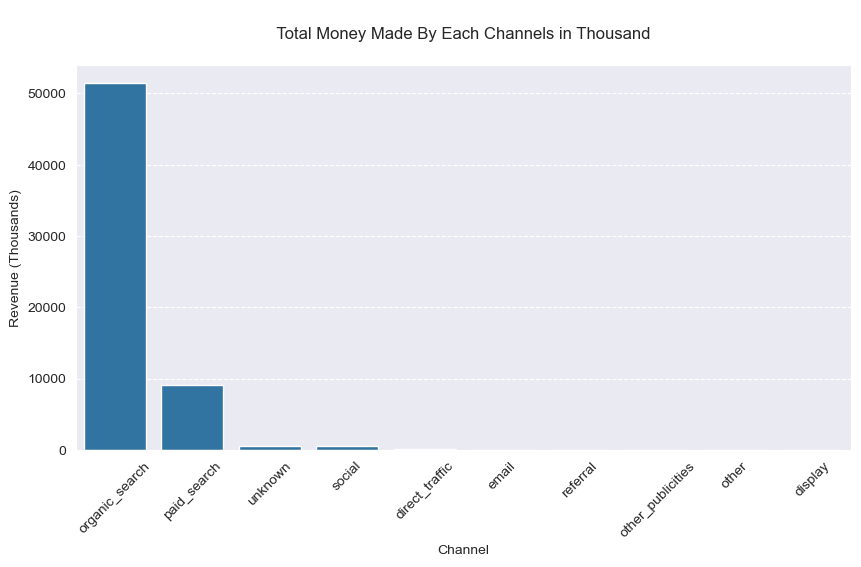

In [324]:
plt.figure(figsize=(10,5))

sns.barplot(data = df,
            x = 'channel',
            y = 'revenue_k').set(title='\n Total Money Made By Each Channels in Thousand \n' );

plt.xlabel('Channel')
plt.ylabel('Revenue (Thousands)')

plt.xticks(rotation=45)

plt.show()

## 📊 Conversion Rate Analysis by Marketing Channel

In this step, we analyze the conversion rate across different marketing channels.

This metric measures how effectively each channel converts Marketing Qualified Leads (MQLs) into closed deals, providing insight into the efficiency and quality of each acquisition source.


In [335]:
query = """
    SELECT
    l.origin,
    COUNT(*) AS total_leads,
    COUNT(d.mql_id) AS won_deals,
    ROUND(
        COUNT(d.mql_id) * 100.0 / COUNT(*),
        2
    ) AS conversion_rate
FROM clean_mql_leads l
LEFT JOIN clean_mql_deals d
    ON l.mql_id = d.mql_id
GROUP BY l.origin
ORDER BY conversion_rate DESC; """

df  = pd.read_sql(query , engine)
df

,origin,total_leads,won_deals,conversion_rate
0,unknown,1159,193,16.65
1,paid_search,1586,195,12.30
2,organic_search,2296,271,11.80
3,direct_traffic,499,56,11.22
4,referral,284,24,8.45
5,social,1350,75,5.56
6,display,118,6,5.08
7,other_publicities,65,3,4.62
8,email,493,15,3.04
9,other,150,4,2.67


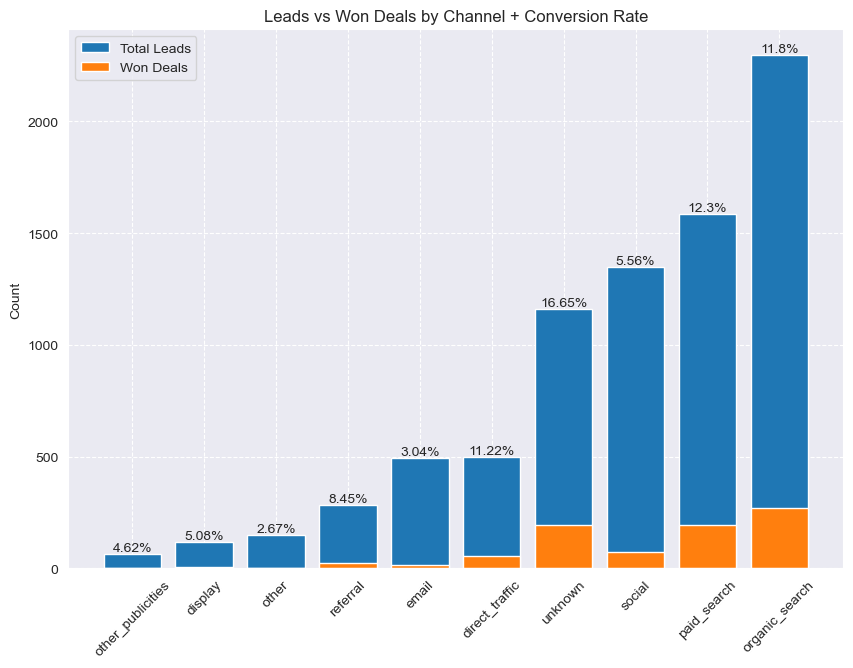

In [337]:
# import matplotlib.pyplot as plt

df = df.sort_values('total_leads')

plt.figure(figsize=(10,7))

# bars
plt.bar(df['origin'], df['total_leads'], label='Total Leads')
plt.bar(df['origin'], df['won_deals'], label='Won Deals')

# labels (conversion rate)
for i in range(len(df)):
    plt.text(
        x=i,
        y=df['total_leads'].iloc[i],
        s=f"{df['conversion_rate'].iloc[i]}%",
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.ylabel('Count')
plt.title('Leads vs Won Deals by Channel + Conversion Rate')
plt.legend()

plt.show()

In [331]:
query = """
SELECT
    l.origin,
    to_char(d.won_date , 'YYYY-MM') as  closed_deals_date,
    ROUND (SUM(d.declared_monthly_revenue) / NULLIF(1000,0) , 0 ) as mntly_rev
FROM clean_mql_deals d
JOIN clean_mql_leads l
    ON d.mql_id = l.mql_id
GROUP BY l.origin  , to_char(d.won_date , 'YYYY-MM')
ORDER BY Closed_deals_date
"""
df = pd.read_sql(query , engine)
df.head()

,origin,closed_deals_date,mntly_rev
0,display,2017-12,0.0
1,paid_search,2017-12,0.0
2,direct_traffic,2018-01,0.0
3,organic_search,2018-01,0.0
4,other,2018-01,0.0


In [332]:
heatmap_data = df.pivot_table(
    index='origin',
    columns='closed_deals_date',
    values='mntly_rev',
    aggfunc='sum',
    fill_value=0
)

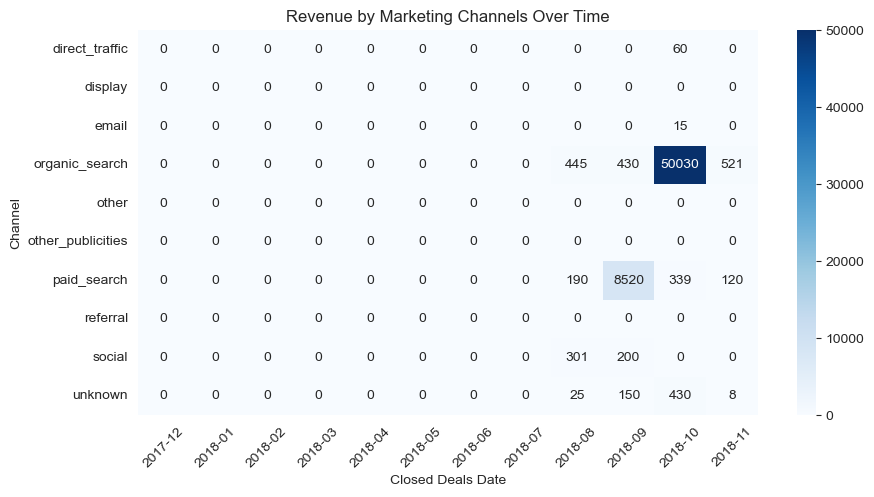

In [333]:
plt.figure(figsize=(10,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='Blues'
)

plt.title('Revenue by Marketing Channels Over Time')
plt.xlabel('Closed Deals Date')
plt.ylabel('Channel')

plt.xticks(rotation=45)

plt.show()


## 📊 Final Marketing Channel Effectiveness Result

**1**. **Organic Search is the most effective marketing channel**, driving the highest customer acquisition volume and generating the largest share of total revenue. This indicates strong performance in inbound traffic and high-quality organic demand.

**2**. **Paid Search ranks second in effectiveness**, contributing a significant portion of both customer acquisitions and revenue. However, its performance is lower compared to Organic Search, suggesting higher acquisition cost or lower conversion efficiency.



## Sales Performance Overview

In [329]:
query = """
    SELECT
    to_char(date_trunc('month' , d.won_date) , 'YYYY-MM') won_date_m,
    sum(declared_monthly_revenue) / 1000 as monthly_revenue

FROM mql_deals d
GROUP BY date_trunc('month',d.won_date)
order by won_date_m ASC
"""
df = pd.read_sql(query , engine)
df

,won_date_m,monthly_revenue
0,2017-12,0.000
1,2018-01,0.000
2,2018-02,0.000
3,2018-03,0.000
4,2018-04,0.000
5,2018-05,0.000
6,2018-06,0.000
7,2018-07,0.000
8,2018-08,961.006
9,2018-09,9300.000


In [189]:
%config Completer.use_jedi = True

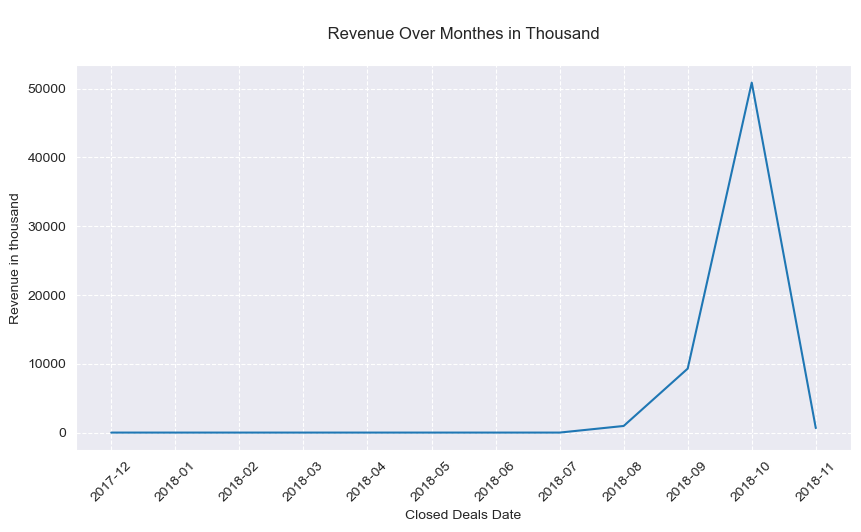

In [330]:
plt.figure(figsize = (10,5))

sns.lineplot(x = 'won_date_m' ,
            y = 'monthly_revenue', 
            data = df).set( title = ' \n Revenue Over Monthes in Thousand \n' 
                            )
plt.xticks(rotation = 45)
plt.xlabel("Closed Deals Date")
plt.ylabel("Revenue in thousand")
plt.grid('white')

plt.show()

In [326]:
query = """
SELECT
    to_char(date_trunc('month' , d.won_date) , 'YYYY-MM') won_date_m,
    count(declared_monthly_revenue) as monthly_sales_count

FROM mql_deals d
GROUP BY date_trunc('month',d.won_date)
order by won_date_m ASC

"""
df = pd.read_sql(query , engine)
df

,won_date_m,monthly_sales_count
0,2017-12,3
1,2018-01,73
2,2018-02,113
3,2018-03,147
4,2018-04,207
5,2018-05,122
6,2018-06,57
7,2018-07,37
8,2018-08,33
9,2018-09,23


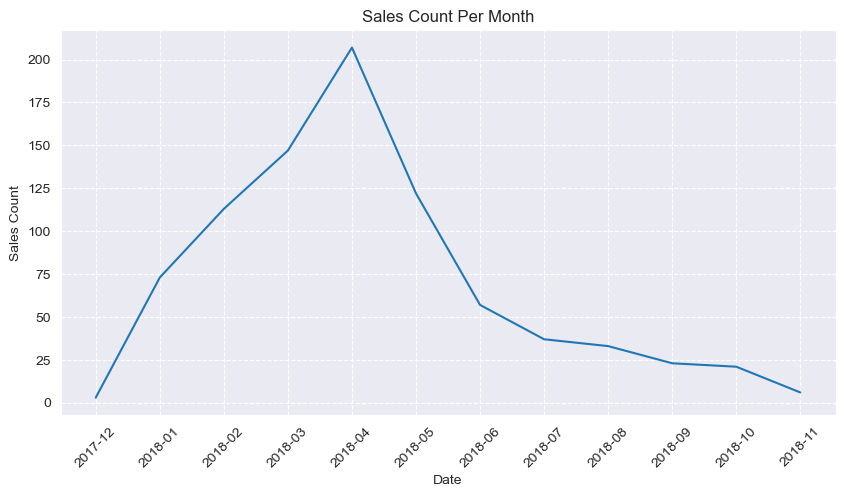

In [327]:
plt.figure(figsize = (10,5))
sns.lineplot(x = 'won_date_m' ,
            y = 'monthly_sales_count',
            data = df)
plt.xticks(rotation = 45)
plt.xlabel('Date')
plt.ylabel('Sales Count')
plt.title('Sales Count Per Month')
plt.show()


## 📊 Key Findings

**1**. **Revenue has shown a positive growth trend over the last three months**, indicating recent improvement in deal value or conversion efficiency.

**2**. **The sales cycle remains relatively long**, as the time gap between lead acquisition and deal closure has stayed consistently high over the past five months, suggesting inefficiencies in the conversion process.

**3**. **Sales volume has been declining steadily over the last seven months**, which may indicate weakening demand or reduced lead quality over time.

### Closed Deal Performance Overview

In [372]:
query = """
SELECT
    business_type,
    COUNT(declared_monthly_revenue) AS total_orders
FROM clean_mql_deals
GROUP BY business_type
ORDER BY total_orders DESC; """

df = pd.read_sql(query, engine)
df

,business_type,total_orders
0,reseller,587
1,manufacturer,242
2,unknown,10
3,other,3


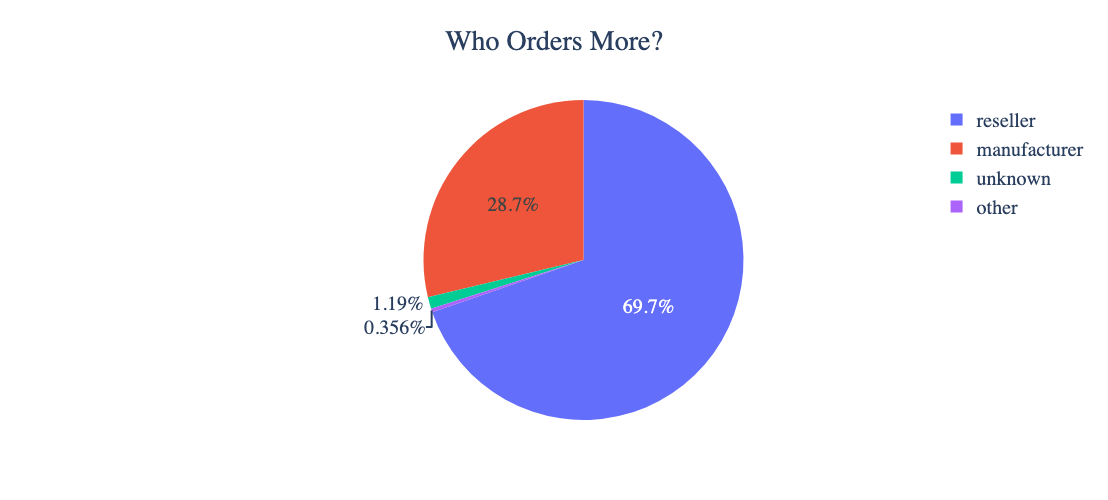

In [373]:
px.pie(
    df,
    names='business_type',
    values='total_orders',
    title='Who Orders More?',
    height=500,
    width=1000
).update_layout(
    title_x=0.5,
    font=dict(family='Moon Heavy', size=20)
)

In [374]:
query = """
SELECT
    business_type,
    SUM(declared_monthly_revenue) AS revenue
FROM clean_mql_deals
GROUP BY business_type
ORDER BY revenue;"""
df = pd.read_sql(query , engine)
df

,business_type,revenue
0,unknown,0.0
1,other,626000.0
2,reseller,10333006.0
3,manufacturer,50825000.0


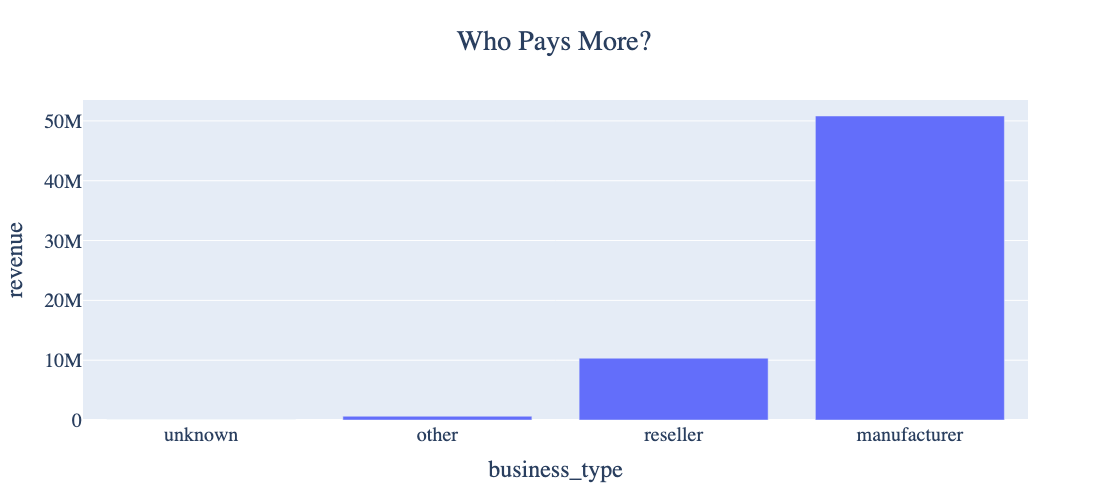

In [375]:
px.bar(
    df,
    x='business_type',
    y='revenue',
    title='Who Pays More?',
    height=500,
    width=1000
).update_layout(
    title_x=0.5,
    font=dict(family='Moon Heavy', size=20)
)

In [378]:
query = """
SELECT
    business_segment,
    ROUND(SUM(declared_monthly_revenue)/1000, 2) AS revenue_k
FROM clean_mql_deals
GROUP BY business_segment
HAVING SUM(declared_monthly_revenue) <> 0

ORDER BY revenue_k;"""
df = pd.read_sql(query , engine)
df

,business_segment,revenue_k
0,watches,1.00
1,food_drink,10.00
2,perfume,15.00
3,party,20.00
4,bed_bath_table,30.00
5,stationery,100.00
6,computers,105.00
7,household_utilities,163.00
8,car_accessories,185.00
9,toys,259.00


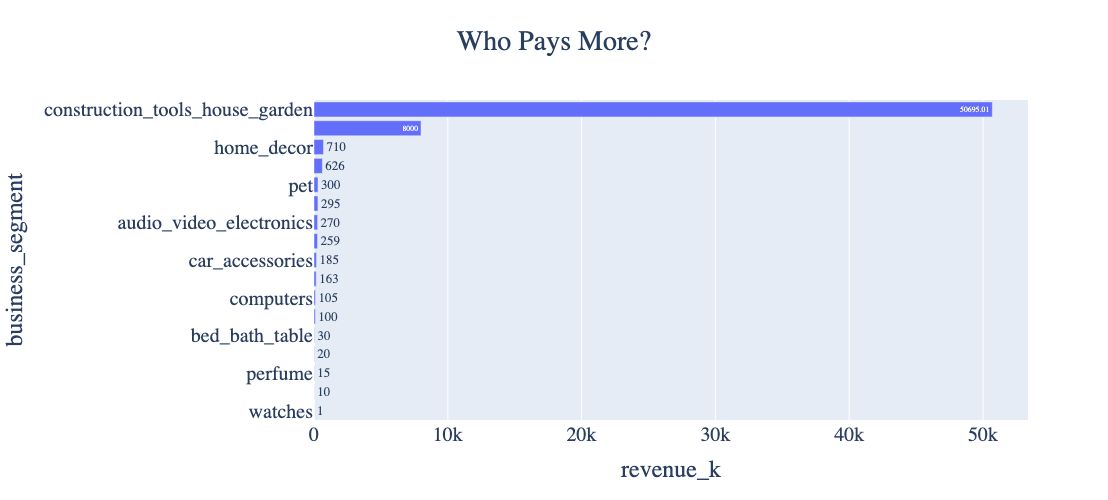

In [379]:
px.bar(
    df,
    x='revenue_k',
    y='business_segment',
    orientation='h',
    title='Who Pays More?',
    height=500,
    width=1000,
    text='revenue_k'
).update_layout(
    title_x=0.5,
    font=dict(family='Moon Heavy', size=20)
)

## 📊 Final Closed Deal Performance Overview

**1**. **Resellers generate the highest number of orders**, however they contribute less total revenue per deal on average.

**2**. **Manufacturers generate fewer orders**, but they contribute significantly higher total revenue, indicating higher value per customer.

**3**. **Top-performing business segments by revenue:**

   * construction_tools_house_garden
   * phone_mobile
   * home_decor
   * pet
   * health_beauty

**4**. **Lowest-performing business segments:**

   * watches
   * food_drink
   * perfume
   * party
   * bed_bath_table



# 📊 Marketing Funnel Report & Story

## 🎯 Executive Summary

The analysis of the Olist marketing funnel reveals that **Organic Search and Paid Search are the primary drivers of both customer acquisition and revenue generation** for the platform.

Despite a **decline in traffic over the last five months**, the platform continues to achieve its **highest revenue levels in the same period**, suggesting improved monetization efficiency or higher-quality leads.

However, the data also highlights a key operational challenge: the **sales cycle remains long**, limiting the ability to convert leads into fast-paying customers.

---

## 📈 Marketing Channel Performance

* **Organic Search** is the most effective acquisition channel, generating the highest number of leads and the largest share of total revenue. This indicates strong SEO performance and high-intent user traffic.

* **Paid Search** is the second most important channel, contributing significantly to both traffic and revenue, although its efficiency is lower compared to Organic Search.

---

## 📊 Key Business Insights

* **Revenue has shown an upward trend over the last three months**, indicating improved deal value or better conversion quality.

* **Sales volume has been steadily decreasing over the last seven months**, suggesting a potential drop in lead inflow or funnel efficiency issues.

* The **average time between lead acquisition and deal closure remains high**, indicating a slow and inefficient conversion process.

---

## 🧩 Customer & Revenue Structure

* **Resellers generate the highest number of orders**, but contribute lower revenue per transaction.

* **Manufacturers generate fewer orders**, but contribute significantly higher revenue per deal, making them higher-value customers.

---

## 🏆 Top Performing Business Segments

* construction_tools_house_garden
* phone_mobile
* home_decor
* pet
* health_beauty

These segments represent the strongest revenue drivers within the platform.

---

## ⚠️ Underperforming Business Segments

* watches
* food_drink
* perfume
* party
* bed_bath_table

These categories contribute minimal revenue and may require reassessment in marketing focus or product strategy.

---

## 💡 Final Conclusion

Overall, the funnel analysis suggests that **the business is driven by strong organic demand but limited by a long and inefficient sales cycle**.

While revenue performance remains strong, the declining sales volume and slow conversion speed highlight opportunities for optimization in lead nurturing and sales process efficiency.

Focusing on improving conversion speed and scaling high-performing channels such as Organic Search could significantly enhance overall funnel performance.
